In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix

import shap
import lime

import joblib

In [2]:
def plot_confusion_matrix(y_true, y_pred, model_name="Model", figsize=(8, 6)):
    """
    Create a nice confusion matrix visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred: predicted labels  
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.colorbar()
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    
    # Add labels
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    plt.yticks([0, 1], ['No Heart Disease', 'Heart Disease'])
    
    # Calculate and display accuracy
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    plt.suptitle(f'Accuracy: {accuracy:.3f}', fontsize=14, y=0.02)
    
    plt.tight_layout()
    plt.show()

     # Print detailed metrics
    print(f"\n{model_name} Performance:")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")
    print(f"Accuracy: {accuracy:.3f}")
    
    # Calculate additional metrics
    precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    
    return cm, accuracy

In [3]:
def plot_roc_curve(y_true, y_pred_proba, model_name="Model", figsize=(8, 6)):
    """
    Create a nice ROC curve visualization for any model
    
    Parameters:
    y_true: actual labels
    y_pred_proba: predicted probabilities (for positive class)
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc_score = roc_auc_score(y_true, y_pred_proba)
    
    plt.figure(figsize=figsize)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'{model_name} (AUC = {auc_score:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print AUC score
    print(f"\n{model_name} ROC AUC Score: {auc_score:.3f}")
    
    # Interpretation
    if auc_score > 0.9:
        print("Excellent performance!")
    elif auc_score > 0.8:
        print("Good performance!")
    elif auc_score > 0.7:
        print("Fair performance")
    elif auc_score > 0.6:
        print("Poor performance")
    else:
        print("Very poor performance")
    
    return fpr, tpr, auc_score

In [4]:
def plot_feature_importance(model, feature_names, model_name="Model", figsize=(10, 6)):
    """
    Plot feature importance for tree-based models
    
    Parameters:
    model: trained tree-based model (e.g., DecisionTreeClassifier, RandomForestClassifier)
    feature_names: list of feature names
    model_name: name of the model for the title
    figsize: figure size tuple
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=figsize)
    plt.title(f'{model_name} - Feature Importances', fontsize=16, fontweight='bold')
    plt.bar(range(len(importances)), importances[indices], align='center', color='skyblue')
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90, fontsize=10)
    plt.ylabel('Importance Score', fontsize=12, fontweight='bold')
    plt.xlabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print feature importance scores
    print(f"\n{model_name} Feature Importances:")
    for i in indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")

In [5]:
data = pd.read_csv('/kaggle/input/heart-prediction-preprocessed/heart_preprocessed_scaled.csv')

In [6]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1],  # Reduced: 0.01 for high n_estimators, 0.1 for balance
    'max_depth': [3, 5, 7],  # Reduced: removed 10 (often leads to overfitting)
    'subsample': [0.8, 1.0],  # Reduced: 0.6 is rarely optimal
    'colsample_bytree': [0.8, 1.0],  # Reduced: 0.6 is rarely optimal
    'gamma': [0, 0.1],  # Reduced: start conservative
    'reg_alpha': [0, 0.1],  # Reduced: L1 regularization
    'reg_lambda': [1, 2],  # Reduced: L2 regularization (keep higher values)
    'scale_pos_weight': [1, 3],  # Reduced: adjust based on your imbalance ratio
    'random_state': [42],
    'tree_method': ['hist'],  # Changed to 'hist' for CPU/GPU auto-detection
    'device': ['cuda']
}
# Total: 3 × 2 × 3 × 2 × 2 × 2 × 2 × 2 × 2 × 1 × 1 = 1,152 combinations

grid_xgb = GridSearchCV(xgb.XGBClassifier(), param_grid=params, cv=5, scoring='f1', verbose=1)

# Fit the model
grid_xgb.fit(X_train, y_train)

# Print explicit confirmation instead of relying on Jupyter's pretty repr
try:
    booster = grid_xgb.best_estimator_.get_booster()
    print('XGBoost fitted. Booster type:', type(booster).__name__)
except Exception:
    print('XGBoost fitted. Booster not retrievable with get_booster().')

print('predict_proba available:', hasattr(grid_xgb.best_estimator_, 'predict_proba'))
print('n_estimators:', getattr(grid_xgb.best_estimator_, 'n_estimators', None))

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits


[12:06:15] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.



XGBoost fitted. Booster type: Booster
predict_proba available: True
n_estimators: 500


In [8]:
print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best cross-validation score: {grid_xgb.best_score_}")

Best parameters: {'colsample_bytree': 1.0, 'device': 'cuda', 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1, 'scale_pos_weight': 3, 'subsample': 1.0, 'tree_method': 'hist'}
Best cross-validation score: 0.8893405848514367


In [9]:
log_reg_pred = grid_xgb.predict(X_test)

In [10]:
print(classification_report(y_test, log_reg_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



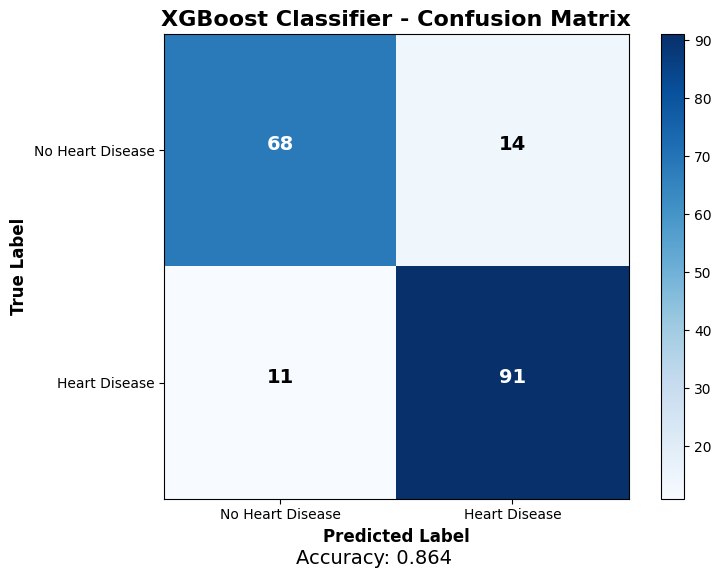


XGBoost Classifier Performance:
True Negatives: 68
False Positives: 14
False Negatives: 11
True Positives: 91
Accuracy: 0.864
Precision: 0.867
Recall: 0.892
F1-Score: 0.879


In [11]:
log_reg_cm, log_reg_acc = plot_confusion_matrix(y_test, log_reg_pred, 'XGBoost Classifier')

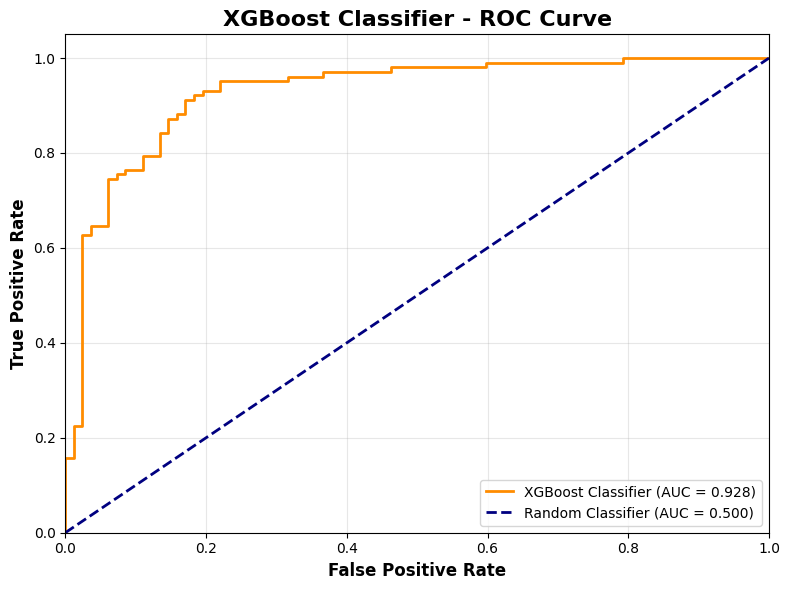


XGBoost Classifier ROC AUC Score: 0.928
Excellent performance!


In [12]:
log_reg_proba = grid_xgb.predict_proba(X_test)[:, 1]
log_reg_fpr, log_reg_tpr, log_reg_thresholds = plot_roc_curve(y_test, log_reg_proba, 'XGBoost Classifier')

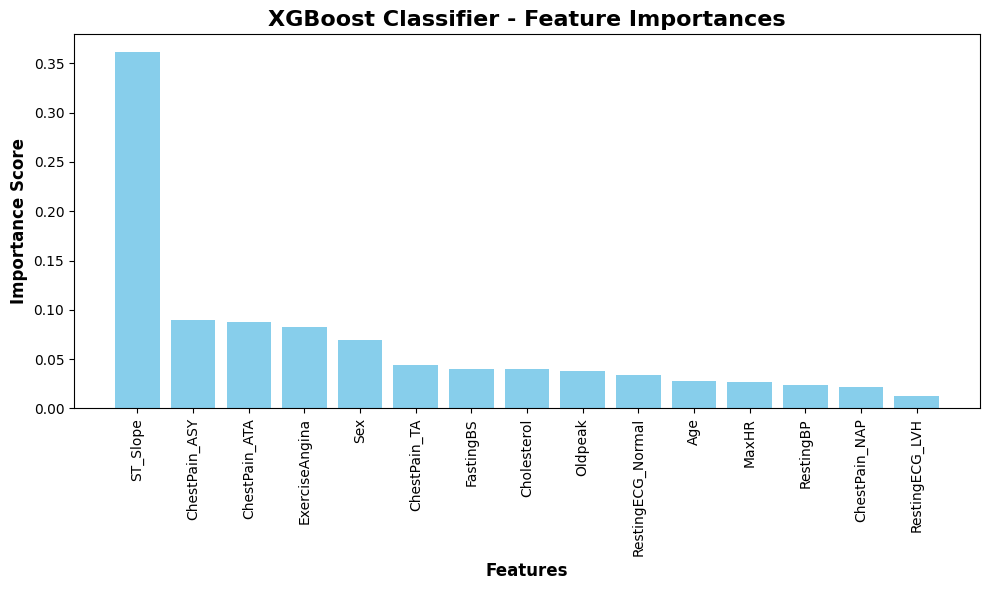


XGBoost Classifier Feature Importances:
ST_Slope: 0.3613
ChestPain_ASY: 0.0899
ChestPain_ATA: 0.0879
ExerciseAngina: 0.0827
Sex: 0.0692
ChestPain_TA: 0.0442
FastingBS: 0.0402
Cholesterol: 0.0396
Oldpeak: 0.0384
RestingECG_Normal: 0.0339
Age: 0.0281
MaxHR: 0.0266
RestingBP: 0.0235
ChestPain_NAP: 0.0218
RestingECG_LVH: 0.0128


In [13]:
plot_feature_importance(grid_xgb.best_estimator_, X.columns, "XGBoost Classifier")

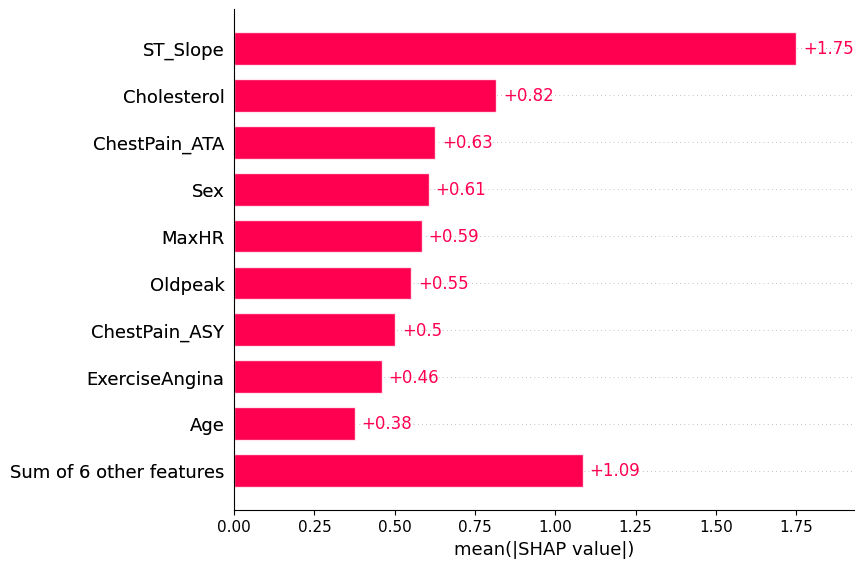

In [14]:
explainer = shap.TreeExplainer(grid_xgb.best_estimator_)
shap_values = explainer.shap_values(X_test)

# shap_values from KernelExplainer can be a list (one array per class) or a 3D numpy array
# with shape (n_samples, n_features, n_classes). Select the positive class (index 1)
# and wrap into a shap.Explanation so shap.plots.bar accepts it.
class_idx = 1

if isinstance(shap_values, list):
	values = shap_values[class_idx]
elif hasattr(shap_values, "shape") and len(shap_values.shape) == 3:
	values = shap_values[..., class_idx]
else:
	# fallback: assume shap_values already in the desired 2D shape
	values = shap_values

base_values = explainer.expected_value[class_idx] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value

shap_exp = shap.Explanation(values=values, base_values=base_values, data=X_test, feature_names=X_test.columns)
shap.plots.bar(shap_exp)

In [15]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=X_train.values, feature_names=X_train.columns, class_names=['No Heart Disease', 'Heart Disease'], mode='classification')
i = 180
exp = lime_explainer.explain_instance(data_row=X_test.values[i], predict_fn=grid_xgb.predict_proba)
exp.show_in_notebook(show_table=True)

In [16]:
joblib.dump(grid_xgb, '/kaggle/working/xgboost_model.pkl')

['/kaggle/working/xgboost_model.pkl']